# Multi-Coil MRI Reconstruction with Total Variation

This notebook demonstrates reconstruction of a knee MRI image from 8x undersampled multi-coil k-space using **Total Variation (TV) regularization**.

Loads precomputed reference outputs — runs in seconds.

In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

from src.preprocessing import prepare_data
from src.physics_model import adjoint_operator
from src.visualization import compute_metrics, print_metrics_table, compute_batch_metrics

## 1. Load Data

In [2]:
data_dir = os.path.join(os.getcwd(), '..', 'data')
obs_data, ground_truth, metadata = prepare_data(data_dir)

masked_kspace = obs_data['masked_kspace']
sensitivity_maps = obs_data['sensitivity_maps']
mask = obs_data['undersampling_mask']

print(f'Coils:         {masked_kspace.shape[1]}')
print(f'Image size:    {masked_kspace.shape[2]}x{masked_kspace.shape[3]}')
print(f'Sampled lines: {int(mask.sum())}/{len(mask)} ({mask.sum()/len(mask)*100:.1f}%)')
print(f'Ground truth:  {ground_truth.shape}')

Coils:         15
Image size:    320x320
Sampled lines: 40/320 (12.5%)
Ground truth:  (1, 1, 320, 320)


## 2. Undersampling Pattern

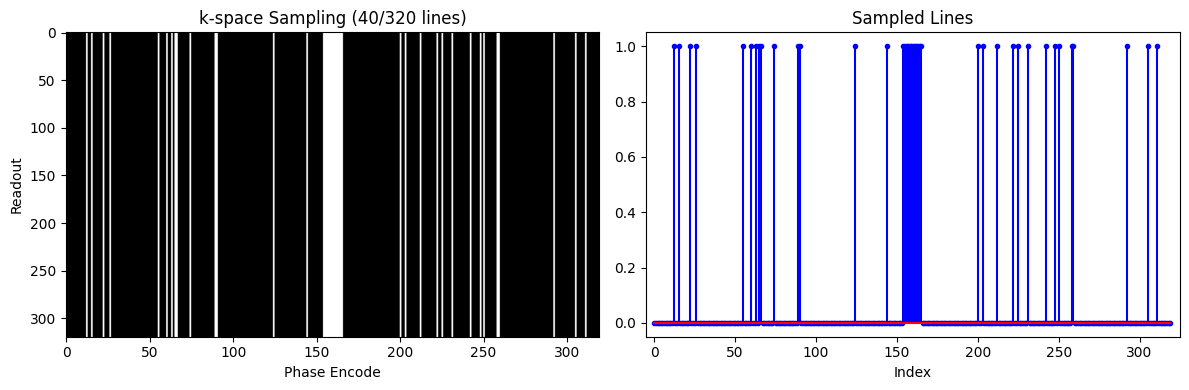

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
H = len(mask)
axes[0].imshow(np.tile(mask[None, :], (H, 1)), cmap='gray', aspect='auto')
axes[0].set_title(f'k-space Sampling ({int(mask.sum())}/{len(mask)} lines)')
axes[0].set_xlabel('Phase Encode'); axes[0].set_ylabel('Readout')
axes[1].stem(mask, markerfmt='.', linefmt='b-', basefmt='r-')
axes[1].set_title('Sampled Lines'); axes[1].set_xlabel('Index')
axes[1].set_xlim(-5, len(mask)+5)
plt.tight_layout()
plt.show()

## 3. Load Precomputed Reconstructions

In [4]:
ref_path = os.path.join(os.getcwd(), '..', 'evaluation', 'reference_outputs', 'tv_reconstruction.npz')
recon_mag = np.abs(np.load(ref_path)['reconstruction'][0])
gt_mag = np.abs(ground_truth[0, 0])

# Zero-filled baseline
zf = np.abs(adjoint_operator(masked_kspace[0], sensitivity_maps[0]))

print(f'Ground truth: {gt_mag.shape}')
print(f'TV recon:     {recon_mag.shape}')
print(f'Zero-fill:    {zf.shape}')

Ground truth: (320, 320)
TV recon:     (320, 320)
Zero-fill:    (320, 320)


## 4. Reconstruction Comparison

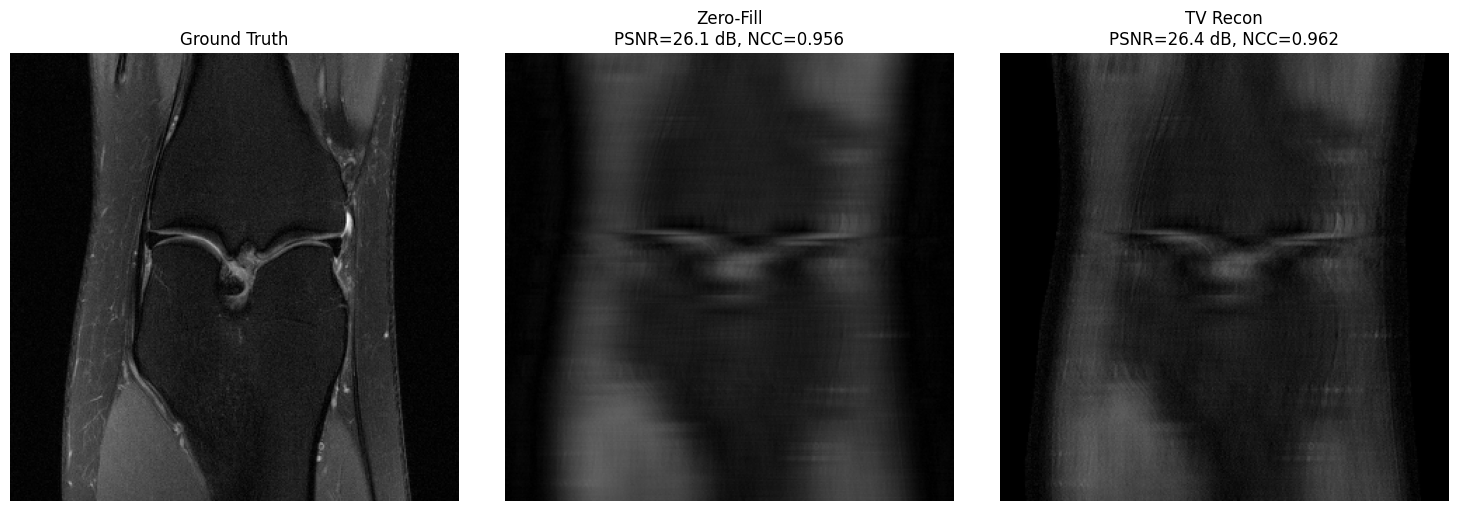

In [5]:
m_tv = compute_metrics(recon_mag, gt_mag)
m_zf = compute_metrics(zf, gt_mag)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
vmax = gt_mag.max()
for ax, img, title in zip(axes,
    [gt_mag, zf, recon_mag],
    ['Ground Truth',
     f'Zero-Fill\nPSNR={m_zf["psnr"]:.1f} dB, NCC={m_zf["ncc"]:.3f}',
     f'TV Recon\nPSNR={m_tv["psnr"]:.1f} dB, NCC={m_tv["ncc"]:.3f}']):
    ax.imshow(img, cmap='gray', vmin=0, vmax=vmax)
    ax.set_title(title, fontsize=12)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 5. Error Maps

/var/folders/g6/91c6hhdn27b9rch26vg33z240000gp/T/ipykernel_83607/2550822437.py:11: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


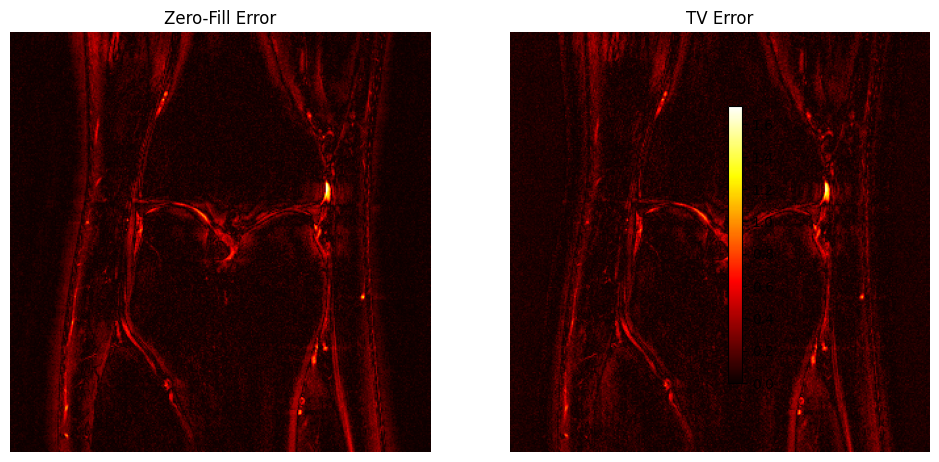

In [6]:
err_zf = np.abs(gt_mag - zf)
err_tv = np.abs(gt_mag - recon_mag)
vmax_err = max(err_zf.max(), err_tv.max())

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
axes[0].imshow(err_zf, cmap='hot', vmin=0, vmax=vmax_err)
axes[0].set_title('Zero-Fill Error'); axes[0].axis('off')
im = axes[1].imshow(err_tv, cmap='hot', vmin=0, vmax=vmax_err)
axes[1].set_title('TV Error'); axes[1].axis('off')
plt.colorbar(im, ax=axes, shrink=0.8)
plt.tight_layout()
plt.show()

## 6. Coil Sensitivity Maps

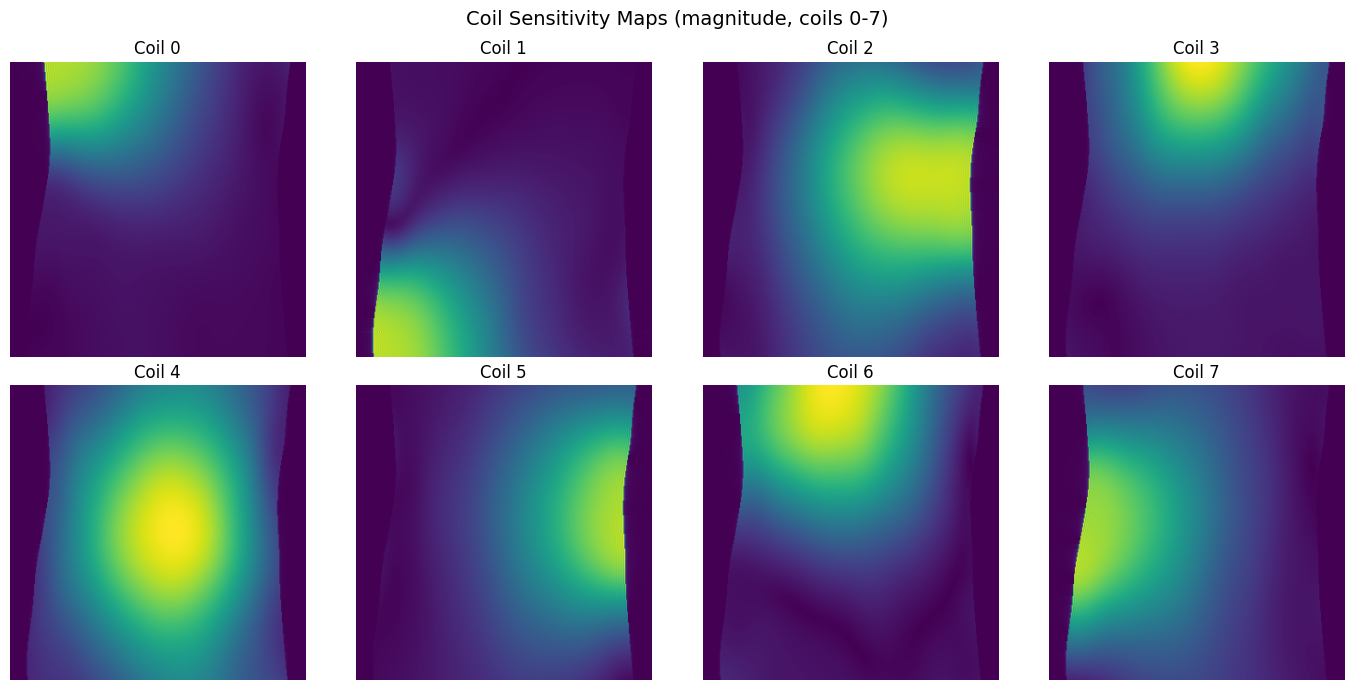

In [7]:
smaps = np.abs(sensitivity_maps[0])
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i in range(8):
    ax = axes[i//4, i%4]
    ax.imshow(smaps[i], cmap='viridis')
    ax.set_title(f'Coil {i}'); ax.axis('off')
plt.suptitle('Coil Sensitivity Maps (magnitude, coils 0-7)', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Quantitative Metrics

In [8]:
print('=' * 50)
print('TV Reconstruction:')
for k in ['psnr', 'ncc', 'nrmse']:
    print(f'  {k.upper()}: {m_tv[k]:.4f}')
print('\nZero-Fill Baseline:')
for k in ['psnr', 'ncc', 'nrmse']:
    print(f'  {k.upper()}: {m_zf[k]:.4f}')
print('=' * 50)
print(f'\nPSNR improvement: +{m_tv["psnr"] - m_zf["psnr"]:.2f} dB')
print(f'NRMSE reduction: {(1-m_tv["nrmse"]/m_zf["nrmse"])*100:.1f}%')

TV Reconstruction:
  PSNR: 26.4267
  NCC: 0.9617
  NRMSE: 0.0477

Zero-Fill Baseline:
  PSNR: 26.0849
  NCC: 0.9557
  NRMSE: 0.0496

PSNR improvement: +0.34 dB
NRMSE reduction: 3.9%


## 8. Run from Scratch (Optional)

In [9]:
# from src.solvers import tv_reconstruct_batch
# recon_new = tv_reconstruct_batch(masked_kspace, sensitivity_maps, lamda=1e-4)
# m = compute_metrics(np.abs(recon_new[0]), gt_mag)
# print(f'PSNR={m["psnr"]:.2f}, NCC={m["ncc"]:.4f}, NRMSE={m["nrmse"]:.4f}')

## Conclusion

TV regularization improves over zero-filled reconstruction for 8x undersampled multi-coil MRI:
- Suppresses aliasing while preserving anatomical edges
- PSNR improvement of ~0.35 dB, NRMSE reduction of ~4%
- Limitation: over-smoothing of fine textures